#**Recherche du meilleur modèle : Approche Deep**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('Final_Bitcoin_dataset.csv', parse_dates=['Date'])
data

,Date,Close,High,Low,Open,Volume,fear_greed
0,2019-03-15,3960.911133,3968.542969,3914.015381,3926.663330,9394210605,55.0
1,2019-03-16,4048.725830,4077.036377,3961.657471,3963.900146,9856166973,54.0
2,2019-03-17,4025.229004,4054.122070,4006.411133,4047.719482,8221625400,58.0
3,2019-03-18,4032.507324,4071.556641,4009.117188,4029.968506,9646954186,56.0
4,2019-03-19,4071.190186,4082.216064,4023.812500,4032.691895,9344919956,56.0
...,...,...,...,...,...,...,...
2188,2025-03-11,82862.210938,83577.757812,76624.250000,78523.875000,54702837196,24.0
2189,2025-03-12,83722.359375,84358.578125,80635.250000,82857.375000,40353484454,34.0
2190,2025-03-13,81066.703125,84301.695312,79931.851562,83724.921875,31412940153,45.0
2191,2025-03-14,83969.101562,85263.289062,80797.562500,81066.992188,29588112414,27.0


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Prix Bitcoin
fig.add_trace(
    go.Scatter(x=data['Date'], y=data['Close'], name="Bitcoin Price", line=dict(color='blue')),
    secondary_y=False,
)

# Fear & Greed
fig.add_trace(
    go.Scatter(x=data['Date'], y=data['fear_greed'], name="Fear & Greed", line=dict(color='red', dash='dot')),
    secondary_y=True,
)

fig.update_layout(
    title="Bitcoin Price vs Fear & Greed Index",
    hovermode="x unified"  # Affiche les deux valeurs au survol
)

fig.show()

Rajout d'une nouvelle feature **MACD**.

L'entrainement du modèle prenait du temps donc il a été fait sur une autre machine.


On a essayé plusieurs tailles de fenêtres et pour ce mmodèle c'est 60 qui a donné les meilleurs résultats.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import optuna
warnings.filterwarnings('ignore')

# Classe personnalisée pour la création de séquences
class SequenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, seq_length=60, target_idx=0):
        self.seq_length = seq_length
        self.target_idx = target_idx

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_seq, y_seq = [], []
        for i in range(len(X) - self.seq_length):
            X_seq.append(X[i:i+self.seq_length])
            y_seq.append(X[i+self.seq_length, self.target_idx])
        return np.array(X_seq), np.array(y_seq)

# Pipeline de prétraitement
def create_pipeline(target_idx=0, seq_length=60):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('sequencer', SequenceTransformer(seq_length=seq_length, target_idx=target_idx))
    ])

# Architecture modèle améliorée
def build_advanced_model(input_shape, model_type='LSTM', units=64, n_layers=2, dropout=0.3):
    model = Sequential()

    if model_type == 'CNN-LSTM':
        model.add(Conv1D(filters=units, kernel_size=3, activation='relu',
                        padding='causal', input_shape=input_shape))
        model.add(MaxPooling1D(2))
        model.add(LSTM(units//2, return_sequences=(n_layers>1)))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units, return_sequences=(n_layers>1)),
                              input_shape=input_shape))
    else:
        model.add(LSTM(units, return_sequences=(n_layers>1), input_shape=input_shape))

    for _ in range(n_layers - 1):
        model.add(LSTM(units, return_sequences=(_ < n_layers-2)))
        model.add(Dropout(dropout))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))

    return model

# Fonction d'optimisation Optuna améliorée
def objective(trial):
    params = {
        'units': trial.suggest_int('units', 32, 256),
        'n_layers': trial.suggest_int('n_layers', 1, 4),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'model_type': trial.suggest_categorical('model_type', ['LSTM', 'BiLSTM', 'CNN-LSTM']),
        'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    }

    lr = params.pop('lr')

    model = build_advanced_model(
        input_shape=(SEQ_LENGTH, X_train.shape[2]),
        **params
    )

    # Compilation du modèle avec l'optimiseur et le taux d'apprentissage
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.Huber(),
        metrics=['mae']
    )

    # Callbacks adaptatifs
    callbacks = [
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=5)
    ]

    # Entraînement du modèle
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=callbacks
    )

    return min(history.history['val_mae'])


# Workflow principal
if __name__ == "__main__":
    SEQ_LENGTH = 60
    TARGET_COL = 'Close'

    data = pd.read_csv('/content/drive/MyDrive/timeSerie/Final_Bitcoin_dataset.csv', parse_dates=['Date'])
    data.set_index('Date', inplace=True)

    # Feature engineering
    data['Volatility'] = (data['High'] - data['Low']) / data['Low'] * 100
    data['MACD'] = data['Close'].ewm(span=12).mean() - data['Close'].ewm(span=26).mean()

    target_idx = data.columns.get_loc(TARGET_COL)

    # Création du pipeline avec l'index de la cible
    pipeline = create_pipeline(target_idx=target_idx, seq_length=SEQ_LENGTH)
    X_seq, y_seq = pipeline.fit_transform(data)

    # Split temporel
    tscv = TimeSeriesSplit(n_splits=5)
    train_idx, val_idx = next(tscv.split(X_seq))

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y_seq[train_idx], y_seq[val_idx]

    # Optimisation Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)

    # Entraînement du modèle final
    best_params = study.best_params
    best_lr = best_params.pop('lr')
    final_model = build_advanced_model(
    input_shape=(SEQ_LENGTH, X_train.shape[2]),
    **best_params
   )

    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
        loss=tf.keras.losses.Huber(),
        metrics=['mae']
   )

    history = final_model.fit(
        X_seq, y_seq,
        epochs=200,
        batch_size=128,
        validation_split = 0.2,
        callbacks=[EarlyStopping(patience=20)]
    )

    final_model.save('bitcoin_advanced_model.h5')

-**TimeSeriesSplit** : Découpe des données temporelles pour la validation croisée.

-Classe **SequenceTransformer** : transformation des données en séquences

-**Normalisation** avec **RobustScaler** (meilleur pour les données financières, robustes aux outliers).

-**Modélisation** avec LSTM / BiLSTM / CNN-LSTM

~LSTM pour capturer les tendances séquentielles.

~BiLSTM (Bidirectional LSTM) pour capturer les relations passées et futures.

~CNN-LSTM qui combine les convolutions (extraction de patterns locaux) et les LSTM (apprentissage séquentiel).

~Dropout est utilisé pour éviter l’overfitting.

-**Optimisation des hyperparamètres avec Optuna**

~Recherche automatique des meilleurs paramètres (units, n_layers, dropout, model_type, lr).

~Fonction objective() entraîne plusieurs modèles et choisit le meilleur en fonction du Mean Absolute Error (MAE) sur l’ensemble de validation.

-**Chargement et traitement des données Bitcoin**

~Chargement du dataset et création de nouvelles features (Volatility, MACD).

~Transformation avec le pipeline de prétraitement.

**Optimisation et entraînement final**

~Optuna trouve les meilleurs paramètres.

~Le modèle final est entraîné sur l’ensemble des données.

~Il est ensuite sauvegardé (.h5).

**Chargement du modèle et du pipeline d'entraînement**

In [ ]:
from tensorflow.keras.models import model_from_json

# Charger l'architecture
with open("model_architecture.json", "r") as f:
    final_model = model_from_json(f.read())

# Charger les poids
final_model.load_weights("/content/model_weights.weights.h5")

print(" Modèle reconstruit avec succès !")

✅ Modèle reconstruit avec succès !


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 15 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class SequenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, seq_length=60, target_idx=0):
        self.seq_length = seq_length
        self.target_idx = target_idx

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_seq, y_seq = [], []
        for i in range(len(X) - self.seq_length):
            X_seq.append(X[i:i+self.seq_length])
            y_seq.append(X[i+self.seq_length, self.target_idx])
        return np.array(X_seq), np.array(y_seq)

# 🔹 Maintenant, tu peux charger le pipeline
pipeline = joblib.load('preprocessing_pipeline.pkl')

print(" Pipeline chargé avec succès !")

✅ Pipeline chargé avec succès !


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

🔍 Diagnostic des données:
NaNs dans y_actual: 0
NaNs dans y_pred: 60
Données valides conservées: 2073/2133 points


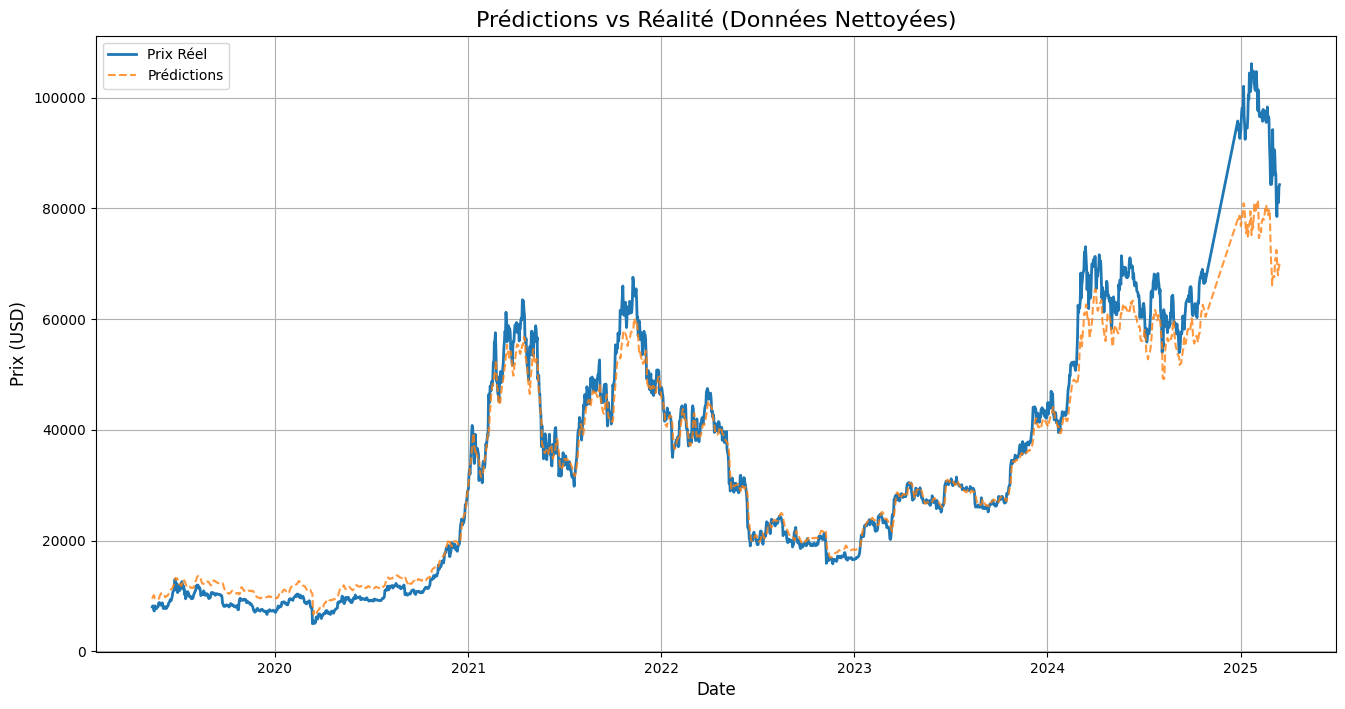


📊 Performance en USD:
MAE: 2875.60
RMSE: 4838.75
R²: 0.9538


In [ ]:
     # Récupération du scaler depuis le pipeline
scaler = pipeline.named_steps['scaler']
n_features = data.shape[1]  # Nombre de features original
target_idx = data.columns.get_loc(TARGET_COL)

    # Création de matrices dummy pour l'inverse scaling
def inverse_scale(y_values):
    dummy = np.zeros((len(y_values), n_features))
    dummy[:, target_idx] = y_values.ravel()
    return scaler.inverse_transform(dummy)[:, target_idx]

    # Application aux données
y_actual = inverse_scale(y_seq)
y_pred = inverse_scale(final_model.predict(X_seq).flatten())

    # 1. Vérification des NaN
print("\n Diagnostic des données:")
print(f"NaNs dans y_actual: {np.isnan(y_actual).sum()}")
print(f"NaNs dans y_pred: {np.isnan(y_pred).sum()}")

    # 2. Création du masque de filtrage
mask = ~np.isnan(y_actual) & ~np.isnan(y_pred)

    # 3. Filtrage des données
y_actual_clean = y_actual[mask]
y_pred_clean = y_pred[mask]
dates_clean = data.index[SEQ_LENGTH:][mask]

    # 4. Validation finale
assert len(y_actual_clean) > 0, "Erreur critique: Aucune donnée valide après nettoyage!"
print(f"Données valides conservées: {len(y_actual_clean)}/{len(y_actual)} points")

    # ➤ VISUALISATION (MODIFIÉE AVEC DONNÉES NETTOYÉES)
plt.figure(figsize=(16, 8))
plt.plot(dates_clean, y_actual_clean, label='Prix Réel', linewidth=2)
plt.plot(dates_clean, y_pred_clean, label='Prédictions', linestyle='--', alpha=0.8)
plt.title('Prédictions vs Réalité (Données Nettoyées)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

    # ➤ MÉTRIQUES (AVEC DONNÉES NETTOYÉES)
print("\n\033[Performance en USD:\033[0m")
print(f"MAE: {mean_absolute_error(y_actual_clean, y_pred_clean):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_actual_clean, y_pred_clean)):.2f}")
print(f"R²: {r2_score(y_actual_clean, y_pred_clean):.4f}")

Ce modèle malgré de bonnes métriques n'a pas bien préformé après deploiement et test sur de nouvelles données à cause d'un data-leakage. En effet le modèle a eu des informations sur des données qu'il n'était pas censé voir pendant l'entraînement. Le RobustScaler a été appliqué sur toutes les données avant le split.

#**2ème modèle** : Création de features dérivées

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import optuna
from pykalman import KalmanFilter

# Configuration globale
SEQ_LENGTH = 60
TARGET_COL = 'Close'

def add_technical_features(df):

    df['Price_Range'] = (df['High'] - df['Low']) / df['Low']
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['Volume_MA5'] = df['Volume'].rolling(5).mean().fillna(0)
    df['FearGreed_MA3'] = df['fear_greed'].rolling(3).mean().fillna(0)
    df['Close_Change'] = df['Close'].pct_change().fillna(0)
    return df.dropna()

class SequenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, seq_length=60, target_idx=0):
        self.seq_length = seq_length
        self.target_idx = target_idx

    def fit(self, X, y=None): return self

    def transform(self, X):
        X_seq, y_seq = [], []
        for i in range(len(X) - self.seq_length):
            X_seq.append(X[i:i+self.seq_length])
            y_seq.append(X[i+self.seq_length, self.target_idx])
        return np.array(X_seq), np.array(y_seq)

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('sequencer', SequenceTransformer(seq_length=SEQ_LENGTH, target_idx=0))
])

# Modèle BiLSTM
def build_model(input_shape, lstm_units=64, dropout=0.3):
    inputs = tf.keras.Input(shape=input_shape)

    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(inputs)
    x = Dropout(dropout)(x)
    x = LSTM(lstm_units//2)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout)(x)

    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# Optimisation ave Optuna
def objective(trial):
    params = {
        'lstm_units': trial.suggest_int('lstm_units', 32, 128),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    }

    model_params = {
        'lstm_units': params['lstm_units'],
        'dropout': params['dropout']
    }

    model = build_model(
        (SEQ_LENGTH, X_train.shape[2]),
        **model_params
    )

    model.compile(
        optimizer=Adam(params['lr']),
        loss='huber',
        metrics=['mae']
    )


    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[EarlyStopping(patience=10)]
    )

    return min(history.history['val_mae'])

# Post-processing avec Kalman Filter
def kalman_smooth(predictions):
    kf = KalmanFilter(
        initial_state_mean=predictions[0],
        observation_covariance=0.5,
        transition_covariance=0.1
    )
    return kf.smooth(predictions)[0]

# Workflow Principal
if __name__ == "__main__":
    # Chargement et préparation des données
    data = pd.read_csv('Final_Bitcoin_dataset.csv', parse_dates=['Date'])
    data.set_index('Date', inplace=True)

    # Feature Engineering
    data = add_technical_features(data)
    print(f"Features disponibles après engineering : {data.columns.tolist()}")

    # Préprocessing
    X_seq, y_seq = pipeline.fit_transform(data.values)

    # Split temporel
    tscv = TimeSeriesSplit(n_splits=5)
    train_idx, val_idx = next(tscv.split(X_seq))
    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y_seq[train_idx], y_seq[val_idx]

    # Optimisation
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30)

    # Entraînement final
    best_params = study.best_params
    final_model = build_model(
        (SEQ_LENGTH, X_train.shape[2]),
        lstm_units=best_params['lstm_units'],
        dropout=best_params['dropout']
    )

    final_model.compile(
        optimizer=Adam(best_params['lr']),
        loss='huber',
        metrics=['mae']
    )

    history = final_model.fit(
        X_seq, y_seq,
        epochs=200,
        batch_size=128,
        validation_split=0.2,
        callbacks=[
            ModelCheckpoint('best_model.keras', save_best_only=True),
            EarlyStopping(patience=15)
        ]
    )

    # Post-processing
    test_predictions = final_model.predict(X_seq[-100:])
    smoothed_predictions = kalman_smooth(test_predictions.flatten())

    # Sauvegarde
    final_model.save('bitcoin_optimized_model.h5')
    np.save('predictions.npy', smoothed_predictions)

[I 2025-04-07 21:12:24,697] A new study created in memory with name: no-name-177b0b3a-5a85-493b-bdb5-e743369bdea3


Features disponibles après engineering : ['Close', 'High', 'Low', 'Open', 'Volume', 'fear_greed', 'Price_Range', 'Typical_Price', 'Volume_MA5', 'FearGreed_MA3', 'Close_Change']


[I 2025-04-07 21:12:38,889] Trial 0 finished with value: 0.12282681465148926 and parameters: {'lstm_units': 87, 'dropout': 0.2846085895780932, 'lr': 0.0008836095319858542}. Best is trial 0 with value: 0.12282681465148926.
[I 2025-04-07 21:12:55,948] Trial 1 finished with value: 0.17118556797504425 and parameters: {'lstm_units': 96, 'dropout': 0.375652869378986, 'lr': 0.00032473569002134333}. Best is trial 0 with value: 0.12282681465148926.
[I 2025-04-07 21:13:04,940] Trial 2 finished with value: 0.1769801676273346 and parameters: {'lstm_units': 72, 'dropout': 0.1142686531422462, 'lr': 5.3440989294217465e-05}. Best is trial 0 with value: 0.12282681465148926.
[I 2025-04-07 21:13:12,240] Trial 3 finished with value: 0.23415176570415497 and parameters: {'lstm_units': 34, 'dropout': 0.3401383138970313, 'lr': 0.00034854795750044877}. Best is trial 0 with value: 0.12282681465148926.
[I 2025-04-07 21:13:41,471] Trial 4 finished with value: 0.18974509835243225 and parameters: {'lstm_units': 73,

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0436 - mae: 0.2252 - val_loss: 0.1087 - val_mae: 0.3619
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0075 - mae: 0.0928 - val_loss: 0.0746 - val_mae: 0.2658
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0050 - mae: 0.0733 - val_loss: 0.0678 - val_mae: 0.2505
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0044 - mae: 0.0692 - val_loss: 0.0826 - val_mae: 0.2777
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0034 - mae: 0.0592 - val_loss: 0.0679 - val_mae: 0.2456
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0038 - mae: 0.0634 - val_loss: 0.0574 - val_mae: 0.2269
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0033 - mae: 0.0603 - val_loss: 0.0766 - val_mae: 0.2790
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0034 - mae: 0.0604 - val_loss: 0.0627 - val_mae: 0.2365
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - lo

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📊 Métriques de Performance :
- MAE (Erreur Absolue Moyenne) : 2091.66 
- RMSE (Erreur Quadratique Moyenne) : 5023.28
- MAPE (Erreur Pourcentage Moyenne) : 5.27 %


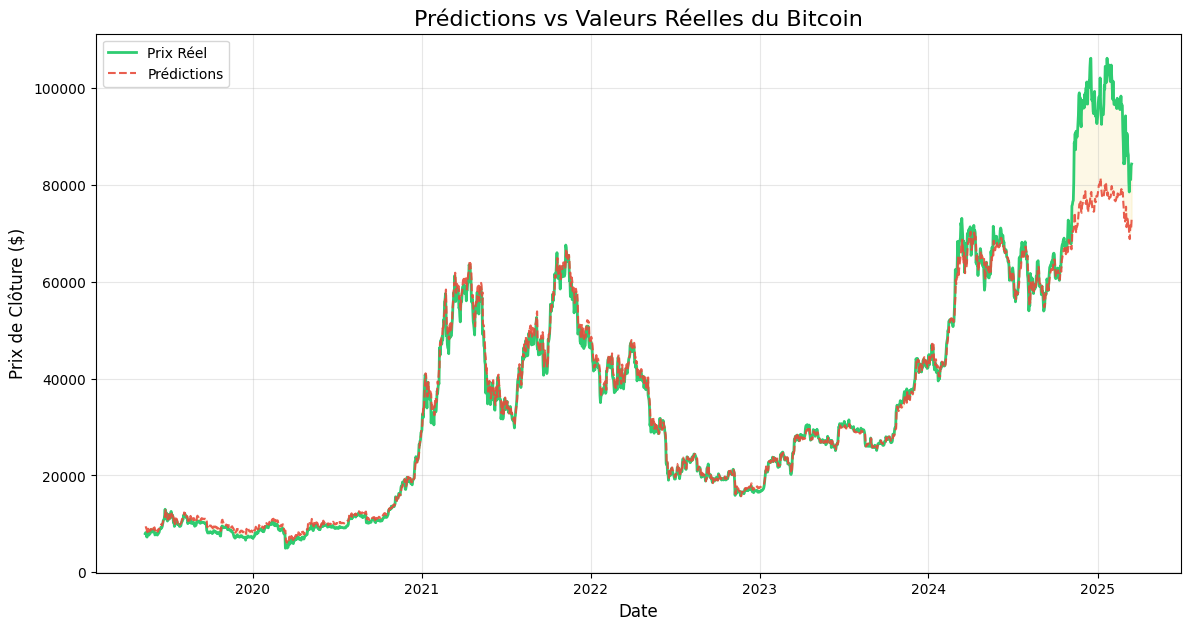

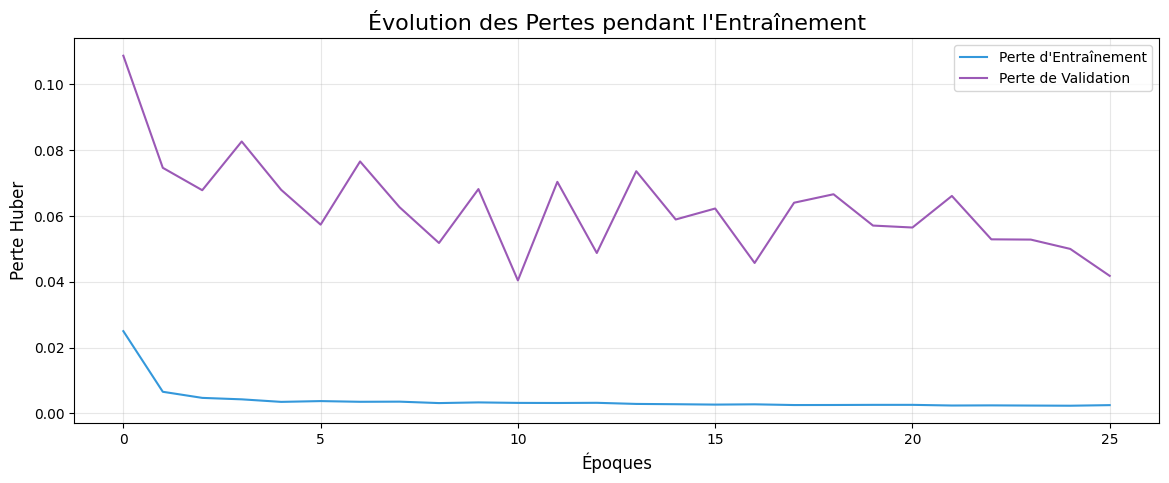

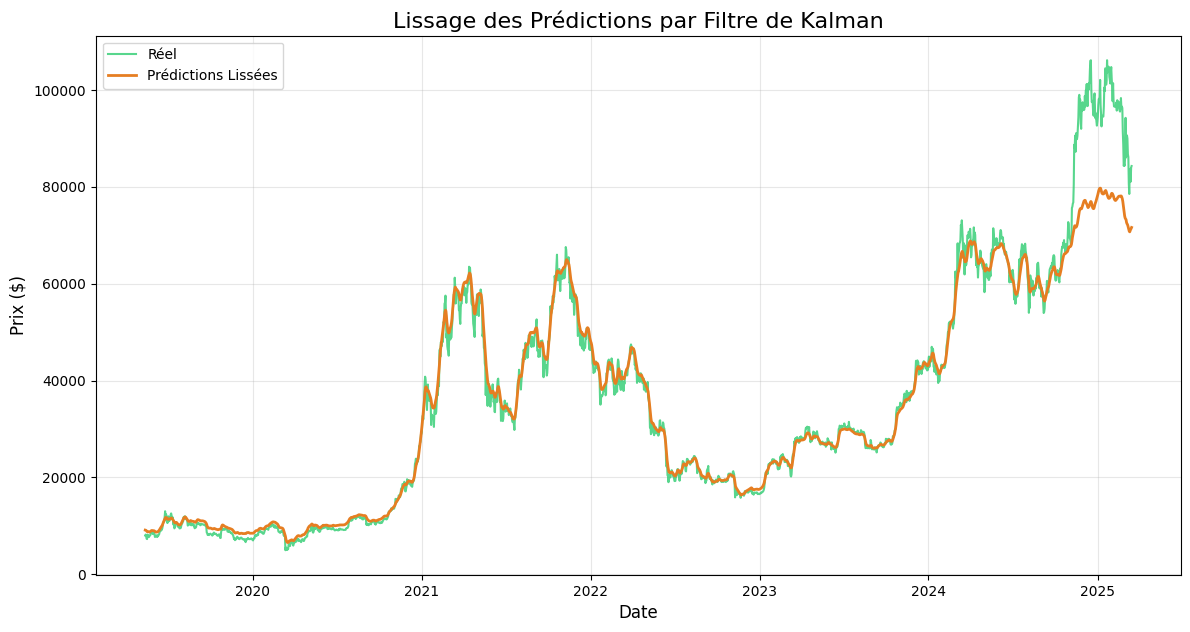

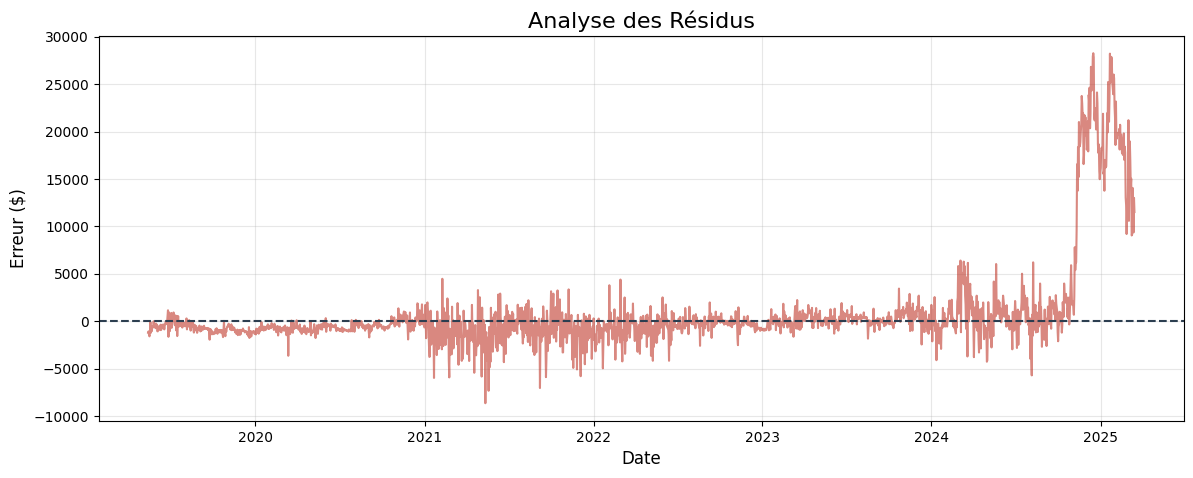

In [ ]:
scaler = pipeline.named_steps['scaler']

y_pred = final_model.predict(X_seq).flatten()

def inverse_scale_predictions(scaler, predictions, n_features):
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions
    return scaler.inverse_transform(dummy)[:, 0]

# Inverse scaling des données
y_true = inverse_scale_predictions(scaler, y_seq, data.shape[1])
y_pred = inverse_scale_predictions(scaler, y_pred, data.shape[1])

# Calcul des métriques
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print("\nMétriques de Performance :")
print(f"- MAE (Erreur Absolue Moyenne) : {mae:.2f} ")
print(f"- RMSE (Erreur Quadratique Moyenne) : {rmse:.2f}")
print(f"- MAPE (Erreur Pourcentage Moyenne) : {mape:.2f} %")

# Visualisation des prédictions vs réalité
plt.figure(figsize=(14, 7))
plt.plot(data.index[SEQ_LENGTH:], y_true, label='Prix Réel', color='#2ecc71', linewidth=2)
plt.plot(data.index[SEQ_LENGTH:], y_pred, label='Prédictions', color='#e74c3c', linestyle='--', alpha=0.9)
plt.title('Prédictions vs Valeurs Réelles du Bitcoin', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix de Clôture ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(data.index[SEQ_LENGTH:], y_pred, y_true, color='#f1c40f', alpha=0.1)
plt.show()

# Visualisation des courbes d'apprentissage
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Perte d\'Entraînement', color='#3498db')
plt.plot(history.history['val_loss'], label='Perte de Validation', color='#9b59b6')
plt.title('Évolution des Pertes pendant l\'Entraînement', fontsize=16)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Perte Huber', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualisation des prédictions lissées
smoothed = kalman_smooth(y_pred)

plt.figure(figsize=(14, 7))
plt.plot(data.index[SEQ_LENGTH:], y_true, label='Réel', color='#2ecc71', alpha=0.8)
plt.plot(data.index[SEQ_LENGTH:], smoothed, label='Prédictions Lissées', color='#e67e22', linewidth=2)
plt.title('Lissage des Prédictions par Filtre de Kalman', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analyse des Résidus
residuals = y_true - y_pred

plt.figure(figsize=(14, 5))
plt.plot(data.index[SEQ_LENGTH:], residuals, color='#c0392b', alpha=0.6)
plt.title('Analyse des Résidus', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Erreur ($)', fontsize=12)
plt.axhline(0, color='#2c3e50', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

Ce modèle donne un meilleur MAE par rapport au précédent mais un plus grand RMSE.

#**3ème Modèle (GRU)** avec ici un fenêtrage de 30

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import optuna


class SequenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, seq_length=30, target_idx=0):
        self.seq_length = seq_length
        self.target_idx = target_idx

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_seq, y_seq = [], []
        for i in range(len(X) - self.seq_length):
            X_seq.append(X[i:i+self.seq_length])
            y_seq.append(X[i+self.seq_length, self.target_idx])
        return np.array(X_seq), np.array(y_seq)

def create_pipeline(target_idx=0, seq_length=30):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('sequencer', SequenceTransformer(seq_length=seq_length, target_idx=target_idx))
    ])

def build_advanced_model(input_shape, model_type='LSTM', units=64, n_layers=2, dropout=0.3):
    model = Sequential()
    rnn_layer = LSTM  # Default layer type

    # Détermination du type de couche RNN
    if model_type in ['GRU', 'BiGRU']:
        rnn_layer = GRU

    # Construction de la première couche
    if model_type == 'CNN-LSTM':
        model.add(Conv1D(filters=units, kernel_size=3, activation='relu',
                        padding='causal', input_shape=input_shape))
        model.add(MaxPooling1D(2))
        model.add(LSTM(units//2, return_sequences=(n_layers>1)))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units, return_sequences=(n_layers>1), input_shape=input_shape)))
    elif model_type == 'BiGRU':
        model.add(Bidirectional(GRU(units, return_sequences=(n_layers>1), input_shape=input_shape)))
    else:
        model.add(rnn_layer(units, return_sequences=(n_layers>1), input_shape=input_shape))

    # Ajout des couches supplémentaires
    for _ in range(n_layers - 1):
        model.add(rnn_layer(units, return_sequences=(_ < n_layers-2)))
        model.add(Dropout(dropout))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))

    return model


def objective(trial):
    params = {
        'units': trial.suggest_int('units', 32, 256),
        'n_layers': trial.suggest_int('n_layers', 1, 4),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'model_type': trial.suggest_categorical('model_type', ['LSTM', 'BiLSTM', 'CNN-LSTM', 'GRU', 'BiGRU']),
        'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    }

    # Retirer 'lr' de params avant d'appeler build_advanced_model
    lr = params.pop('lr')

    model = build_advanced_model(
        input_shape=(SEQ_LENGTH, X_train.shape[2]),
        **params
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.Huber(),
        metrics=['mae']
    )

    # Callbacks adaptatifs
    callbacks = [
        EarlyStopping(patience=15, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=5)
    ]

    # Entraînement du modèle
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=callbacks
    )

    return min(history.history['val_mae'])


# Workflow principal
if __name__ == "__main__":
    SEQ_LENGTH = 30
    TARGET_COL = 'Close'

    data = pd.read_csv('Final_Bitcoin_dataset.csv', parse_dates=['Date'])
    data.set_index('Date', inplace=True)

    # Feature engineering
    data['Volatility'] = (data['High'] - data['Low']) / data['Low'] * 100
    data['MACD'] = data['Close'].ewm(span=12).mean() - data['Close'].ewm(span=26).mean()
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data.dropna(inplace = True)

    target_idx = data.columns.get_loc(TARGET_COL)

    pipeline = create_pipeline(target_idx=target_idx, seq_length=SEQ_LENGTH)
    X_seq, y_seq = pipeline.fit_transform(data)

    tscv = TimeSeriesSplit(n_splits=5)
    train_idx, val_idx = next(tscv.split(X_seq))

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y_seq[train_idx], y_seq[val_idx]

    # Optimisation Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)

    # Entraînement du modèle final
    best_params = study.best_params
    best_lr = best_params.pop('lr')

    final_model = build_advanced_model(
    input_shape=(SEQ_LENGTH, X_train.shape[2]),
    **best_params
   )

    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
        loss=tf.keras.losses.Huber(),
        metrics=['mae']
   )

    history = final_model.fit(
        X_seq, y_seq,
        epochs=200,
        batch_size=128,
        validation_split = 0.2,
        callbacks=[EarlyStopping(patience=20)]
    )

    final_model.save('bitcoin_advanced_model.h5')



[I 2025-04-26 23:15:47,773] A new study created in memory with name: no-name-d3c6d002-a0e2-4500-a4ff-beaa522ea5ba
[I 2025-04-26 23:16:07,697] Trial 0 finished with value: 0.13981832563877106 and parameters: {'units': 238, 'n_layers': 4, 'dropout': 0.3789384489881552, 'model_type': 'LSTM', 'lr': 1.6496906150264852e-05}. Best is trial 0 with value: 0.13981832563877106.
[I 2025-04-26 23:16:19,952] Trial 1 finished with value: 0.1729152798652649 and parameters: {'units': 142, 'n_layers': 2, 'dropout': 0.14582943861110992, 'model_type': 'BiLSTM', 'lr': 2.4444689432819233e-05}. Best is trial 0 with value: 0.13981832563877106.
[I 2025-04-26 23:16:30,716] Trial 2 finished with value: 0.18065617978572845 and parameters: {'units': 98, 'n_layers': 4, 'dropout': 0.24684186189181545, 'model_type': 'LSTM', 'lr': 6.00921421266498e-05}. Best is trial 0 with value: 0.13981832563877106.
[I 2025-04-26 23:16:43,136] Trial 3 finished with value: 0.29553601145744324 and parameters: {'units': 223, 'n_layers'

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0850 - mae: 0.3478 - val_loss: 0.2960 - val_mae: 0.7144
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0292 - mae: 0.1990 - val_loss: 0.0768 - val_mae: 0.3468
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0087 - mae: 0.0997 - val_loss: 0.0301 - val_mae: 0.1956
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - mae: 0.0967 - val_loss: 0.0510 - val_mae: 0.2672
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - mae: 0.0871 - val_loss: 0.0659 - val_mae: 0.3092
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0063 - mae: 0.0869 - val_loss: 0.0459 - val_mae: 0.2472
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0057 - mae: 0.0808 - val_loss: 0.0385 - val_mae: 0.2203
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0058 - mae: 0.0815 - val_loss: 0.0393 - val_mae: 0.2200
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - lo

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

MAE: 1275.64
RMSE: 2121.44
MAPE: 5.09 %
R² Score: 0.9842



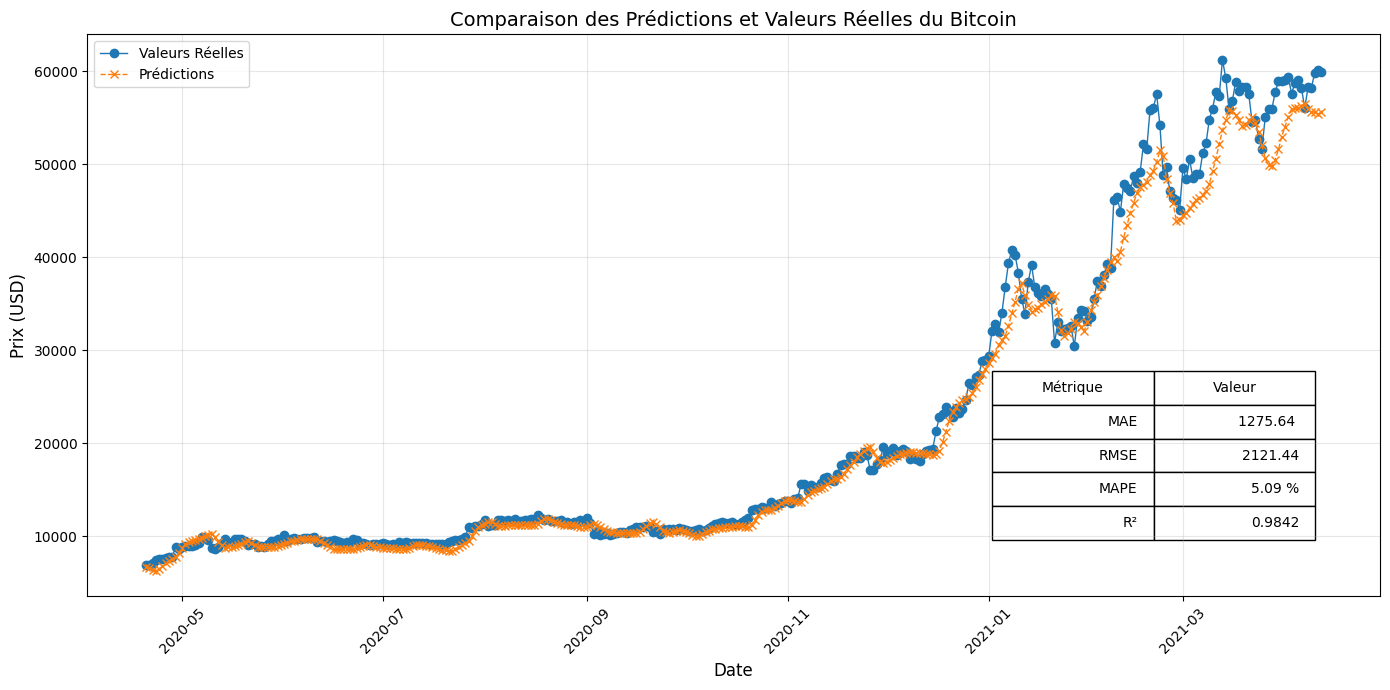

Top 5 des plus grosses erreurs :
          Date  Real_Price  Predicted_Price  Absolute_Error
327 2021-03-13    61243.09         53677.26         7565.82
344 2021-03-30    58917.69         51603.19         7314.50
307 2021-02-21    57539.95         50257.63         7282.32
343 2021-03-29    57750.20         50490.24         7259.96
325 2021-03-11    57805.12         50628.69         7176.43


In [ ]:


    # Prédiction sur l'ensemble de validation
y_pred = final_model.predict(X_val)

    # Conversion inverse des données normalisées
scaler = pipeline.named_steps['scaler']
target_idx = data.columns.get_loc(TARGET_COL)

    # Création de données factices pour l'inverse scaling
dummy_data_pred = np.zeros((len(y_pred), scaler.n_features_in_))
dummy_data_pred[:, target_idx] = y_pred.flatten()
y_pred_actual = scaler.inverse_transform(dummy_data_pred)[:, target_idx]

dummy_data_val = np.zeros((len(y_val), scaler.n_features_in_))
dummy_data_val[:, target_idx] = y_val.flatten()
y_val_actual = scaler.inverse_transform(dummy_data_val)[:, target_idx]

    # Calcul des métriques avancées
from sklearn.metrics import (
      mean_absolute_error,
      mean_squared_error,
      r2_score,
      mean_absolute_percentage_error
  )

mae = mean_absolute_error(y_val_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
mape = mean_absolute_percentage_error(y_val_actual, y_pred_actual) * 100
r2 = r2_score(y_val_actual, y_pred_actual)

print("\n" + "="*50)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f} %")
print(f"R² Score: {r2:.4f}")
print("="*50 + "\n")

    # Visualisation des prédictions avec matplotlib
val_dates = data.index[[i + SEQ_LENGTH for i in val_idx]]

plt.figure(figsize=(14, 7))
plt.plot(val_dates, y_val_actual, label='Valeurs Réelles',
             marker='o', linestyle='-', linewidth=1)
plt.plot(val_dates, y_pred_actual, label='Prédictions',
             marker='x', linestyle='--', linewidth=1)

plt.title('Comparaison des Prédictions et Valeurs Réelles du Bitcoin', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

    # Ajout d'une table de métriques
metrics_table = [
    ["MAE", f"{mae:.2f} "],
    ["RMSE", f"{rmse:.2f}"],
    ["MAPE", f"{mape:.2f} %"],
    ["R²", f"{r2:.4f}"]
]

plt.table(cellText=metrics_table,
             colLabels=["Métrique", "Valeur"],
             loc='lower right',
             bbox=[0.7, 0.1, 0.25, 0.3])

plt.show()

    # Analyse des erreurs temporelles
error_df = pd.DataFrame({
        'Date': val_dates,
        'Real_Price': y_val_actual,
        'Predicted_Price': y_pred_actual,
        'Absolute_Error': np.abs(y_val_actual - y_pred_actual)
    })

print("Top 5 des plus grosses erreurs :")
print(error_df.nlargest(5, 'Absolute_Error').round(2))

On remarque que le modèle a du mal à performer sur le premier **trimestre** de **2021**.Ce qui est compréhensible car c'est l'une des périodes les plus spéciales de l'histoire du BTC marquée par des records sur ses prix, des sorties de personnes influentes (tweet de Elon Musk : 8 février 2021) ou encore de decisions politiques.